<a href="https://colab.research.google.com/github/Magdyibrahim112/MNIST-Handwritten-Digit-Classification-using-CNN_DL_/blob/main/Deep_Learning_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Deep Learning Project - MNIST CNN Experiments (FINAL)

Libray

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

import matplotlib.pyplot as plt
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Hyperparameters

In [ ]:
batch_size = 32
epochs = 5
learning_rate = 0.001

Data_Processing

In [ ]:
# Preprocessing
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
    #(mean, std)
])

Load_dataset

In [ ]:
full_train_dataset = datasets.MNIST(
    "./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    "./data",
    train=False,
    download=True,
    transform=transform
)
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size

train_data, val_data = random_split(
    full_train_dataset,
    [train_size, val_size]
)
train_loader = DataLoader(
    train_data,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_data,
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)


MODEL 1 : SIMPLE CNN

In [ ]:
class SimpleCNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(1, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),

            nn.Linear(32 * 7 * 7, 128),
            nn.ReLU(),

            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.classifier(self.features(x))

MODEL 2 : ENHANCED CNN

In [ ]:
class EnhancedCNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(

            nn.Conv2d(1, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Dropout(0.25),

            nn.Flatten(),

            nn.Linear(64 * 7 * 7, 256),
            nn.ReLU(),

            nn.Dropout(0.5),

            nn.Linear(256, 10)
        )

    def forward(self, x):
        return self.model(x)

TRAINING FUNCTION

In [ ]:
def run_experiment(model, name):

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    train_losses, train_accs = [], []
    val_losses, val_accs = [], []

    print("\n" + "="*60)
    print(f"START TRAINING: {name}")
    print("="*60)

    for epoch in range(epochs):

        model.train()
        total_loss, correct, total = 0, 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            preds = torch.argmax(outputs, 1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_losses.append(total_loss / len(train_loader))
        train_accs.append(100 * correct / total)

        # VALIDATION
        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item()
                preds = torch.argmax(outputs, 1)

                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

        val_losses.append(val_loss / len(val_loader))
        val_accs.append(100 * val_correct / val_total)
        print(
    f"Epoch [{epoch+1}/{epochs}] - {name} | "
    f"Train Loss: {train_losses[-1]:.4f} | "
    f"Train Acc: {train_accs[-1]:.2f}% | "
    f"Val Loss: {val_losses[-1]:.4f} | "
    f"Val Acc: {val_accs[-1]:.2f}%"
)


    # TEST

    model.eval()
    test_preds, test_labels = [], []

    correct, total = 0, 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            preds = torch.argmax(outputs, 1)

            test_preds.extend(preds.cpu().numpy())
            test_labels.extend(labels.cpu().numpy())

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    test_acc = 100 * correct / total

    return train_losses, train_accs, val_losses, val_accs, test_acc


RUN MODELS & CURVES

In [ ]:
# RUN MODELS

model1 = SimpleCNN().to(device)
model2 = EnhancedCNN().to(device)

loss1, acc1, vloss1, vacc1, test1 = run_experiment(model1, "Simple CNN")
loss2, acc2, vloss2, vacc2, test2 = run_experiment(model2, "Enhanced CNN")

# FINAL RESULTS
print("\n================ FINAL RESULTS ==============\n")
print(f"Simple CNN Accuracy   : {test1:.2f}%")
print(f"Enhanced CNN Accuracy : {test2:.2f}%")
print("===============================================")


START TRAINING: Simple CNN
Epoch [1/5] - Simple CNN | Train Loss: 0.1610 | Train Acc: 94.94% | Val Loss: 0.0791 | Val Acc: 97.53%
Epoch [2/5] - Simple CNN | Train Loss: 0.0509 | Train Acc: 98.42% | Val Loss: 0.0477 | Val Acc: 98.53%
Epoch [3/5] - Simple CNN | Train Loss: 0.0342 | Train Acc: 98.91% | Val Loss: 0.0499 | Val Acc: 98.59%
Epoch [4/5] - Simple CNN | Train Loss: 0.0253 | Train Acc: 99.17% | Val Loss: 0.0355 | Val Acc: 98.94%
Epoch [5/5] - Simple CNN | Train Loss: 0.0195 | Train Acc: 99.36% | Val Loss: 0.0391 | Val Acc: 98.86%

START TRAINING: Enhanced CNN
Epoch [1/5] - Enhanced CNN | Train Loss: 0.1976 | Train Acc: 93.87% | Val Loss: 0.0604 | Val Acc: 98.17%
Epoch [2/5] - Enhanced CNN | Train Loss: 0.0940 | Train Acc: 97.17% | Val Loss: 0.0451 | Val Acc: 98.62%
Epoch [3/5] - Enhanced CNN | Train Loss: 0.0746 | Train Acc: 97.76% | Val Loss: 0.0412 | Val Acc: 98.74%
Epoch [4/5] - Enhanced CNN | Train Loss: 0.0613 | Train Acc: 98.16% | Val Loss: 0.0437 | Val Acc: 98.68%
Epoch [

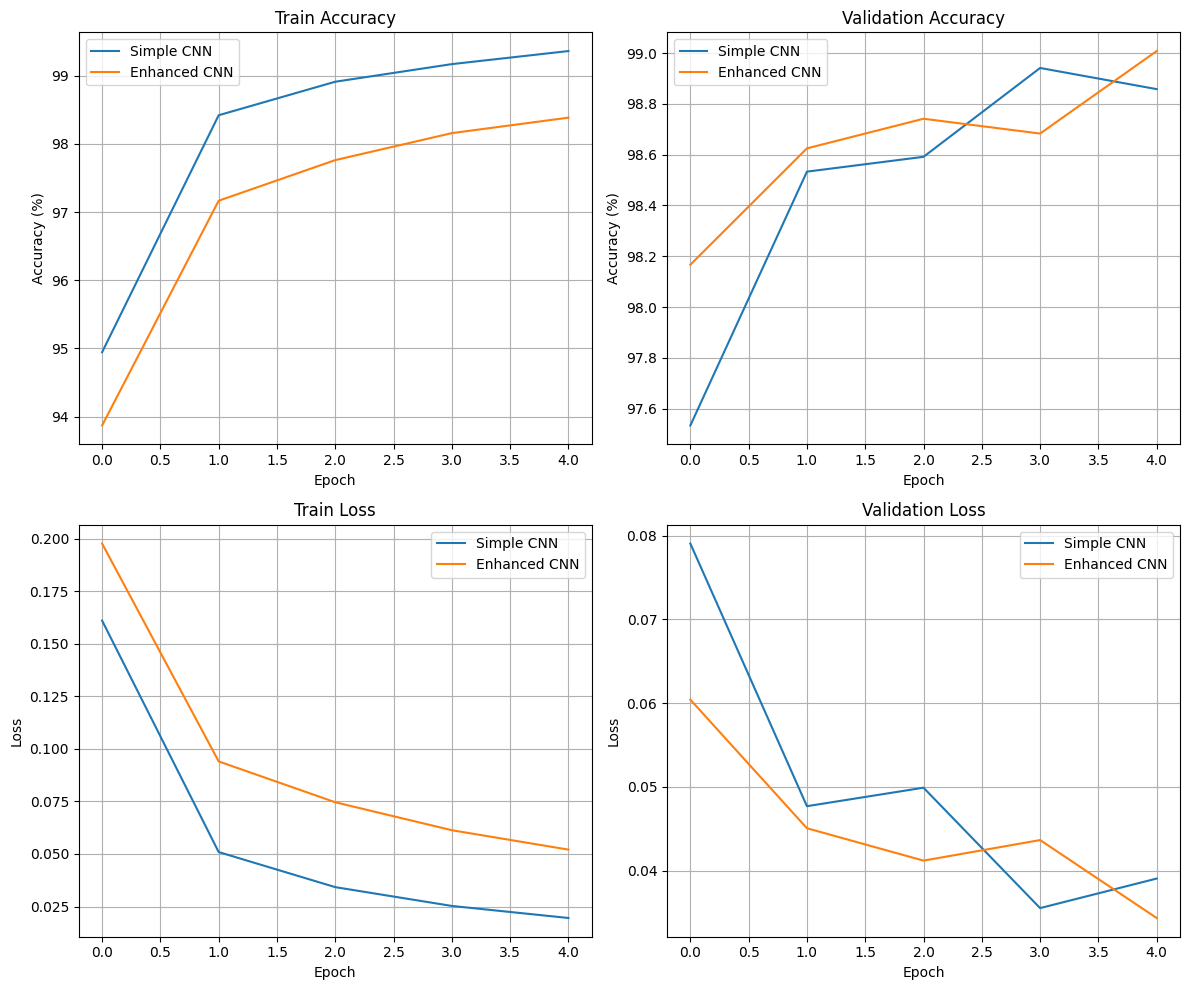

In [ ]:
import os
os.makedirs("results", exist_ok=True)

plt.figure(figsize=(12,10))

# ================= 1) TRAIN ACCURACY =================
plt.subplot(2,2,1)
plt.plot(acc1, label="Simple CNN")
plt.plot(acc2, label="Enhanced CNN")
plt.title("Train Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.grid()

# ================= 2) VALIDATION ACCURACY =================
plt.subplot(2,2,2)
plt.plot(vacc1, label="Simple CNN")
plt.plot(vacc2, label="Enhanced CNN")
plt.title("Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.grid()

# ================= 3) TRAIN LOSS =================
plt.subplot(2,2,3)
plt.plot(loss1, label="Simple CNN")
plt.plot(loss2, label="Enhanced CNN")
plt.title("Train Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid()

# ================= 4) VALIDATION LOSS =================
plt.subplot(2,2,4)
plt.plot(vloss1, label="Simple CNN")
plt.plot(vloss2, label="Enhanced CNN")
plt.title("Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid()

plt.tight_layout()

plt.savefig("results/cnn_curves.png", dpi=300, bbox_inches='tight')

plt.show()

In [1]:
%%writefile main.py

Writing main.py
